In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from results_utils import load_results, aggregate_results

sns.set_theme(style="whitegrid")

GEOM_BASE = "../results/boundary_tracking_gwps_geometry/gwps_n60_ws3"
GEOM_REGEX = r".*_cbo_unknown_dr2_boundary_EI_200_1.pickle"
THREE_BASE = "../results/gwps_three"
PDF_DIR = "PDFs"
os.makedirs(PDF_DIR, exist_ok=True)

# label -> (regex, color, drop_first)
# drop_first trims CBO's extra leading Best_Y point (Best_Y only; Per_trial_Y is aligned)
METHODS = {
    "CBO-U": (r".*_cbo_unknown_dr2_results_200_1.pickle", "red", False),
    "CBO": (r".*_cbo_results_200_1.pickle", "black", True),
    "Random": (r".*_cbo_results_random_200_1.pickle", "green", False),
}


def curve(results, experiment, drop_first=False):
    mean, std = aggregate_results(results, experiment)
    if drop_first and experiment == "Best_Y":
        mean, std = mean[1:], std[1:]
    return mean, std


def _plot_on_ax(ax, experiment):
    mean, std = curve(load_results(GEOM_BASE, GEOM_REGEX), experiment)
    x = range(len(mean))
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color="purple")
    ax.plot(x, mean, label="CBO-U-Geo", color="purple", linewidth=2)

    for label, (regex, color, drop_first) in METHODS.items():
        mean, std = curve(load_results(THREE_BASE, regex), experiment, drop_first)
        x = range(len(mean))
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
        ax.plot(x, mean, label=label, color=color, linewidth=2)

    ax.set_xlabel("Trial")
    ax.set_ylabel(experiment)
    ax.grid(True)
    ax.legend()


def _show(fig, pdf_name):
    fig.tight_layout()
    fig.savefig(f"{PDF_DIR}/{pdf_name}.pdf", bbox_inches="tight")
    display(fig)
    plt.close(fig)


def plot_experiment(experiment):
    fig, ax = plt.subplots(figsize=(8, 5))
    _plot_on_ax(ax, experiment)
    ax.set_title(f"gwps - {experiment}")
    _show(fig, f"gwps_{experiment}")


def plot_stacked():
    fig, axes = plt.subplots(2, 1, figsize=(8, 10))
    for ax, experiment in zip(axes, ["Best_Y", "Per_trial_Y"]):
        _plot_on_ax(ax, experiment)
        ax.set_title(f"K562 - {experiment}")
    _show(fig, "gwps")

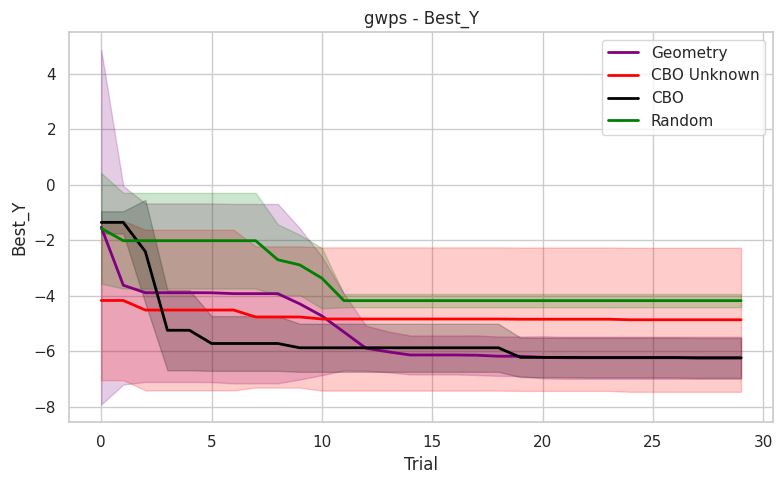

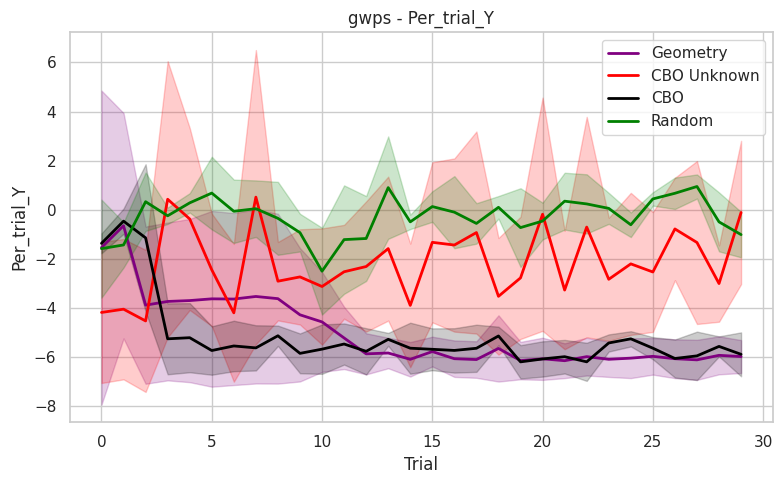

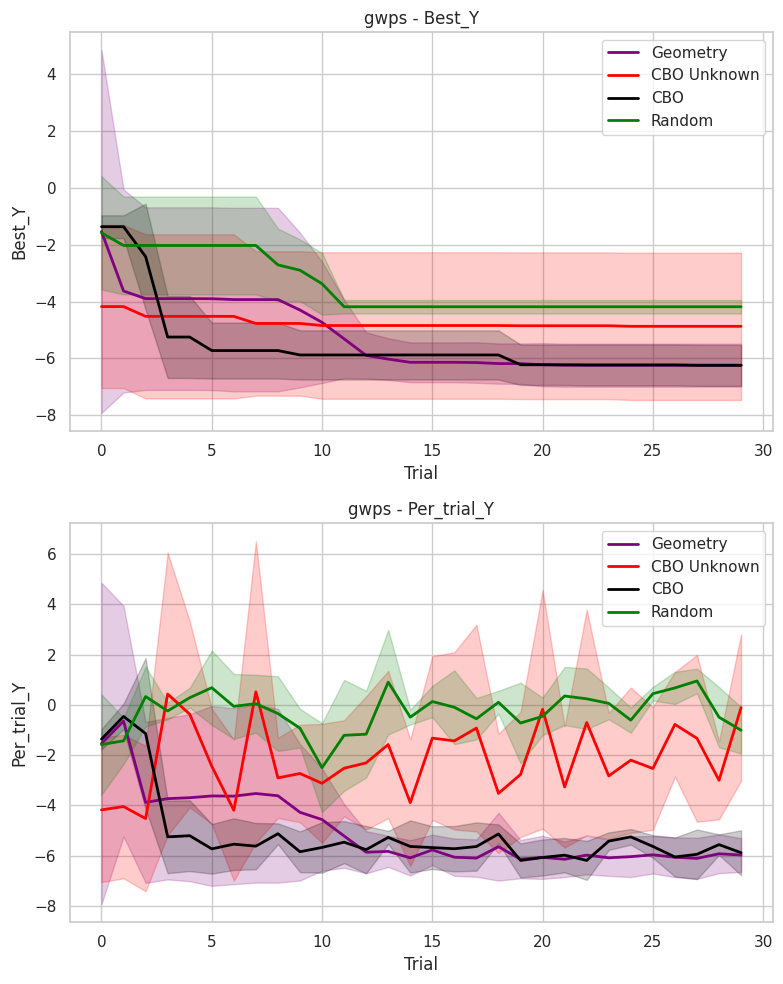

In [4]:
# Single-panel figures -> PDFs/gwps_<experiment>.pdf
plot_experiment("Best_Y")
plot_experiment("Per_trial_Y")

# Best_Y over Per_trial_Y -> PDFs/gwps.pdf
plot_stacked()

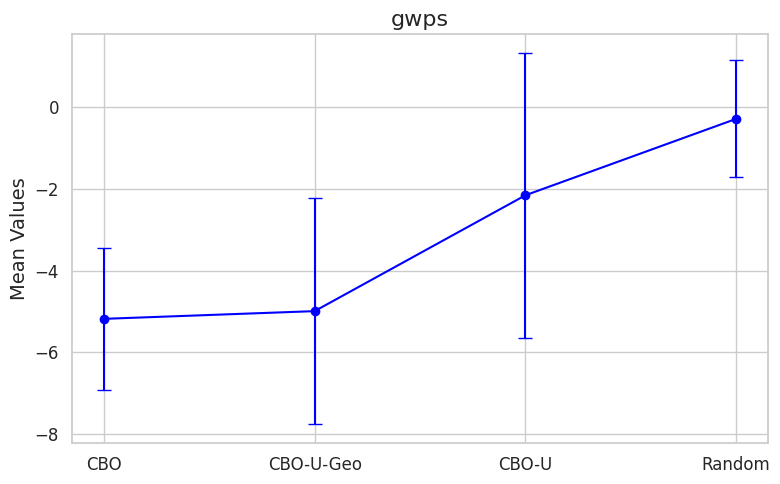

In [ ]:
import os

# mean value = mean of Per_trial_Y pooled across all runs/trials (as all_means does)
def mean_value(base, regex):
    if not os.path.isdir(base):
        return np.nan, 0.0
    results = load_results(base, regex)
    if not results:
        return np.nan, 0.0
    pooled = np.hstack([r["Per_trial_Y"] for r in results])
    return pooled.mean(), pooled.std()


def summarise():
    method_labels = ["CBO", "CBO-U-Geo", "CBO-U", "Random"]
    specs = [
        (THREE_BASE, r".*_cbo_results_200_1.pickle"),
        (GEOM_BASE, GEOM_REGEX),
        (THREE_BASE, r".*_cbo_unknown_dr2_results_200_1.pickle"),
        (THREE_BASE, r".*_cbo_results_random_200_1.pickle"),
    ]
    means, stds = zip(*[mean_value(b, rx) for b, rx in specs])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(method_labels, means, yerr=stds, marker="o", capsize=5,
                linestyle="-", color="blue")
    ax.tick_params(axis="both", labelsize=12)
    ax.set_title("K562", fontsize=16)
    ax.set_ylabel("Mean Values", fontsize=14)
    _show(fig, "gwps_mean_summary")


summarise()